In [71]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec
import typing as t

max_robots = 10
algs = {
    "namo": "C-NAMO Repulsive DR",
    "namo_ndr": "C-NAMO no DR",
    "namo_ncr": "C-NAMO no CR",
    "snamo": "S-NAMO Social DR",
    "snamo_ndr": "S-NAMO no DR",
    "snamo_ncr": "S-NAMO no CR",
}

scenario = 'intersections'
#scenario = 'willow_garage_multi_shape'
data = pandas.read_csv(f"../report_{scenario}.csv")
data["succeeded"] = data["succeeded"].astype(int)
data_successes = data[data["succeeded"] == 1]
sum_goals_per_agent_per_sim = data.groupby(['n_robots', 'algorithm', 'sim_id', 'agent_id']).sum().reset_index()
max_goals_per_agent_per_sim = data.drop(columns='agent_id').groupby(['n_robots', 'algorithm', 'sim_id']).max().reset_index()[['n_robots', 'algorithm', 'n_steps']]
sum_goals_per_agent_per_sim['succeeded'] /= 50
avg_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).mean()
std_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).std()
count_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).count()

avg_make_span = max_goals_per_agent_per_sim.groupby(['n_robots', 'algorithm']).mean()
std_make_span = max_goals_per_agent_per_sim.groupby(['n_robots', 'algorithm']).std()

data = data.drop(columns=["agent_id", "sim_id"])
success_rates = data.groupby(['n_robots','algorithm'])['succeeded'].mean().reset_index()


In [72]:
avg_make_span

n_steps
n_robots algorithm         
1        namo        228.85
         namo_ncr    228.85
         namo_ndr    228.85
         snamo       168.75
         snamo_ncr   168.75
         snamo_ndr   168.75
2        namo       1023.05
         namo_ncr    158.90
         namo_ndr    258.75
         snamo       590.30
         snamo_ncr   140.25
         snamo_ndr   220.65
3        namo       1029.20
         namo_ncr    132.00
         namo_ndr    269.15
         snamo       805.80
         snamo_ncr   129.75
         snamo_ndr   264.95
4        namo        908.65
         namo_ncr    110.55
         namo_ndr    330.35
         snamo       886.45
         snamo_ncr   118.95
         snamo_ndr   298.00
5        namo       1111.80
         namo_ncr    101.05
         namo_ndr    336.20
         snamo      1179.30
         snamo_ncr   100.00
         snamo_ndr   328.95
6        namo       1079.40
         namo_ncr     91.30
         namo_ndr    333.25
         snamo      1196.55
         snamo_ncr   101.70
         snamo_ndr   304.25
7        namo       1020.35
         namo_ncr     86.00
         namo_ndr    337.80
         snamo      1165.70
         snamo_ncr    88.35
         snamo_ndr   266.45
8        namo        844.30
         namo_ncr     79.80
         namo_ndr    306.20
         snamo      1055.15
         snamo_ncr    83.40
         snamo_ndr   282.95
9        namo        865.90
         namo_ncr     86.50
         namo_ndr    308.40
         snamo      1010.95
         snamo_ncr    83.40
         snamo_ndr   259.30
10       namo        757.50
         namo_ncr     66.70
         namo_ndr    277.40
         snamo       996.75
         snamo_ncr    76.10
         snamo_ndr   291.95

In [73]:
avg_per_agent.loc[[(1, 'namo'),(1, 'snamo'),(5, 'namo'),(5, 'snamo'),(10, 'namo'),(10, 'snamo')]][['succeeded', 'distance_traveled', 'n_transfers', 'replans', 'planning_time']]

succeeded  distance_traveled  n_transfers  replans  \
n_robots algorithm                                                       
1        namo          0.9680       36291.548512       23.300   50.000   
         snamo         0.9810       29988.118295       19.600   50.000   
5        namo          0.7098       55796.657367       18.150  226.590   
         snamo         0.7112       39870.505509       11.430  234.410   
10       namo          0.3174       38705.321862        8.365  380.030   
         snamo         0.3733       34685.642002        5.570  357.425   

                    planning_time  
n_robots algorithm                 
1        namo          110.556895  
         snamo         252.391477  
5        namo          520.271805  
         snamo         807.826687  
10       namo          837.956584  
         snamo        1165.516486

In [74]:
std_per_agent.loc[[(1, 'namo'),(1, 'snamo'),(5, 'namo'),(5, 'snamo'),(10, 'namo'),(10, 'snamo')]][['succeeded', 'distance_traveled', 'n_transfers', 'replans', 'planning_time']]

succeeded  distance_traveled  n_transfers    replans  \
n_robots algorithm                                                         
1        namo        0.101650       10248.030106     4.921489   0.000000   
         snamo       0.022919        4352.182971     2.562893   0.000000   
5        namo        0.131303       28791.955712     5.592880  65.795381   
         snamo       0.119336       12394.517001     4.097930  49.345432   
10       namo        0.120607       18316.630670     4.210751  72.770025   
         snamo       0.150821       15010.064801     3.085889  88.099786   

                    planning_time  
n_robots algorithm                 
1        namo           18.301520  
         snamo          15.625356  
5        namo          124.026205  
         snamo         186.153519  
10       namo          144.304677  
         snamo         343.769367

In [75]:
success_rates

,n_robots,algorithm,succeeded
0,1,namo,0.968000
1,1,namo_ncr,0.968000
2,1,namo_ndr,0.968000
3,1,snamo,0.981000
4,1,snamo_ncr,0.981000
5,1,snamo_ndr,0.981000
6,2,namo,0.929500
7,2,namo_ncr,0.457500
8,2,namo_ndr,0.756000
9,2,snamo,0.928000


In [76]:
def plot_metric_by_num_robots(
    *,
    ax: Axes,
    algs: t.Dict[str, str],
    max_robots: int,
    avg,
    std,
    ylabel: str,
    show_legend: bool = False,
    show_std: bool = False,
    show_std2: bool = False
):
    fig_legend = plt.figure("Legend")

    lines = []
    labels = []
    for alg, title in algs.items():
        means = np.array([avg.loc[(i, alg)] for i in range(1, max_robots + 1)])
        stds = np.array([std.loc[(i, alg)] for i in range(1, max_robots + 1)])
        (line,) = ax.plot(
            range(1, max_robots + 1),
            means,
            label=title,
        )
        lines.append(line)
        labels.append(title)
        if show_std:
            ax.fill_between(
                x=range(1, max_robots + 1),
                y1=means - stds,
                y2=means + stds,
                alpha=0.2,
            )
        #------ JSA
        if show_std2:
            (line_stda,) = ax.plot(
            range(1, max_robots + 1),
            means - stds,
            label=title,
            linestyle = 'dotted',
            color=line.get_color(),
            alpha=0.7,
            linewidth = 0.8,
          )
            (line_stdb,) = ax.plot(
            range(1, max_robots + 1),
            means + stds,
            label=title,
            linestyle = 'dotted',
            color=line.get_color(),
            alpha=0.7,
            linewidth = 0.8,
          )
    fig_legend.legend(lines, labels, loc='center', frameon=False)
    fig_legend.savefig(f'{scenario}_legend.png', bbox_inches='tight')
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])

    #------ JSA
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])
    #ax.grid(color = 'white', linestyle = '--', linewidth = 0.8,axis = 'y')
    #ax.grid(color = 'gray', linestyle = '--', linewidth = 0.8,axis = 'y')
    ax.grid(color = '#DDDFE5', linestyle = '--', linewidth = 1.0,axis = 'y')
    ax.grid(color = '#DDDFE5', linestyle = '--', linewidth = 1.0,axis = 'x')
    #ax.grid(color = '#ACADAF', linestyle = '--', linewidth = 0.8,axis = 'y')
    #ax.grid(color = '#ACADAF', linestyle = '--', linewidth = 0.8,axis = 'x')



    ax.set_facecolor("#F5F8F8")

    ax.spines['bottom'].set_color('#000')
    #ax.spines['top'].set_color('#C6C6D1')
    ax.spines['top'].set_color('white')
    #ax.spines['right'].set_color('#C6C6D1')
    ax.spines['right'].set_color('white')
    ax.spines['left'].set_color('#000')

    ax.tick_params(axis='x', colors='#000',labelsize= 15)
    ax.tick_params(axis='y', colors='#000',labelsize= 15)

    ax.yaxis.label.set_color('#000')
    ax.xaxis.label.set_color('#000')



    # ax.set_facecolor("whitesmoke")
    # ax.set_facecolor("lightgrey")
    # ax.set_facecolor("aliceblue")

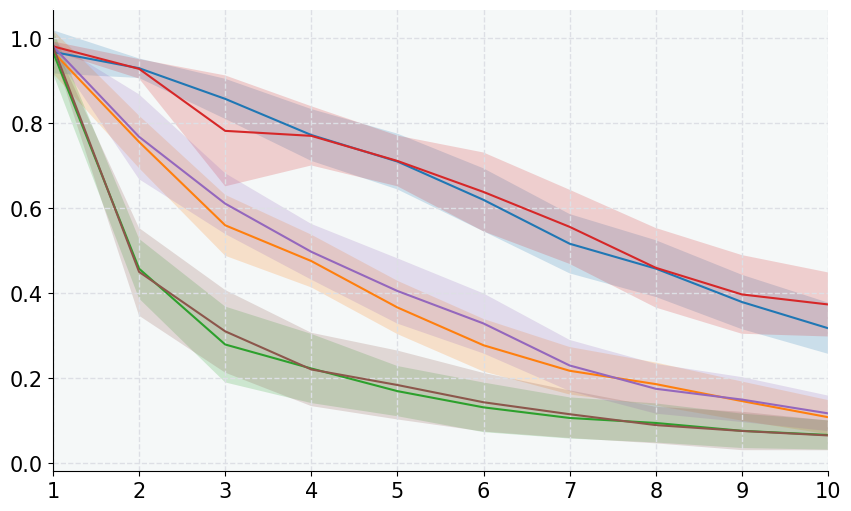

<Figure size 640x480 with 0 Axes>

In [77]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['succeeded'],
    std=std_per_agent['succeeded'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Goal Success Rate",
    show_std=True,
    show_std2=False,
)
fig.savefig(f'{scenario}_success_rates.png', bbox_inches='tight')

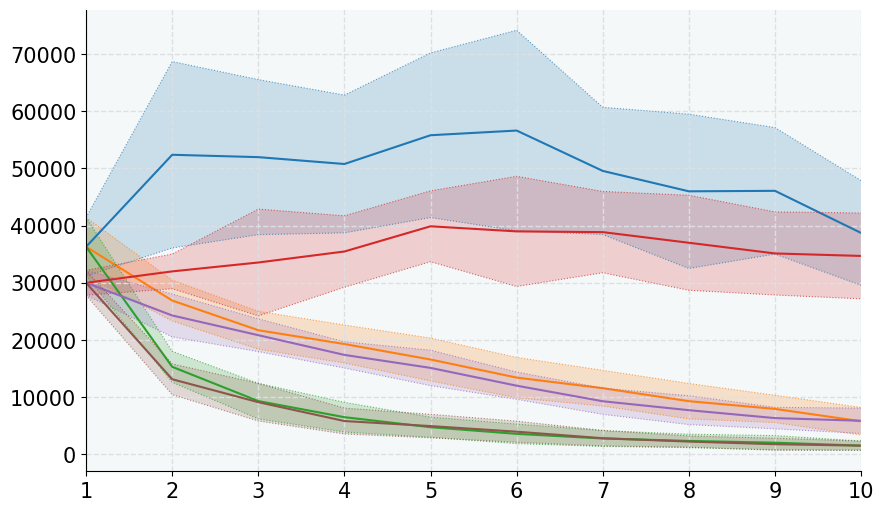

<Figure size 640x480 with 0 Axes>

In [78]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['distance_traveled'],
    std=std_per_agent['distance_traveled'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_distance.png', bbox_inches='tight')

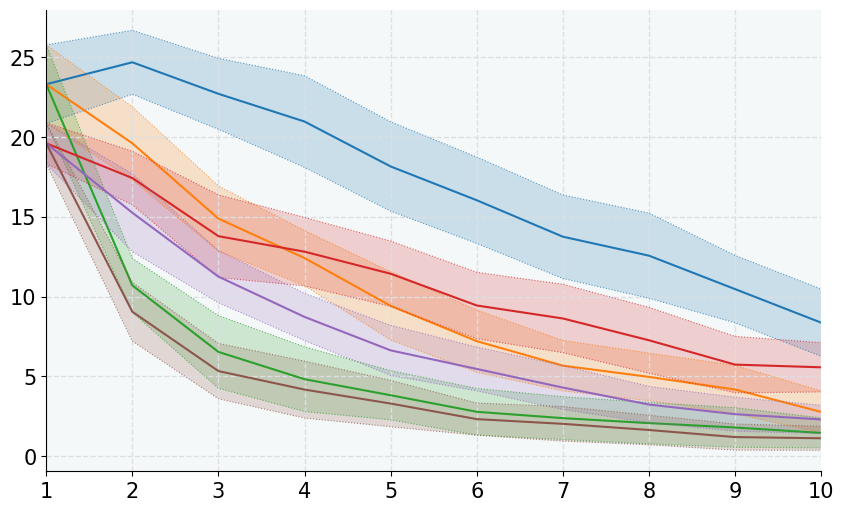

<Figure size 640x480 with 0 Axes>

In [79]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_transfers'],
    std=std_per_agent['n_transfers'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Transfers",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_transfers.png', bbox_inches='tight')

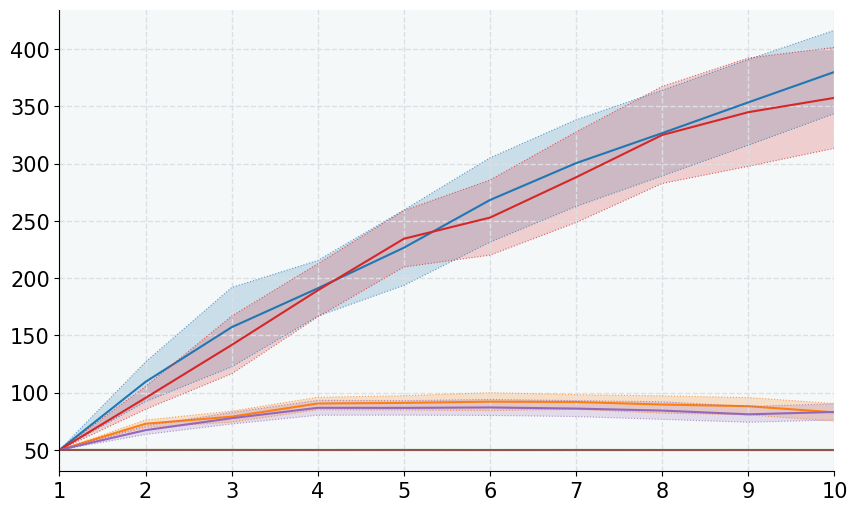

<Figure size 640x480 with 0 Axes>

In [80]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['replans'],
    std=std_per_agent['replans'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Replans",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_replans.png', bbox_inches='tight')

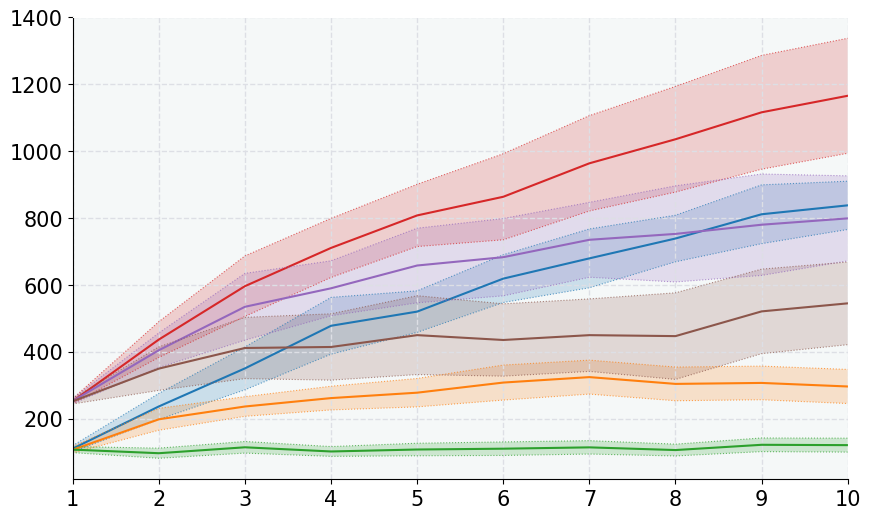

<Figure size 640x480 with 0 Axes>

In [81]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['planning_time'],
    std=std_per_agent['planning_time'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_planning_time.png', bbox_inches='tight')

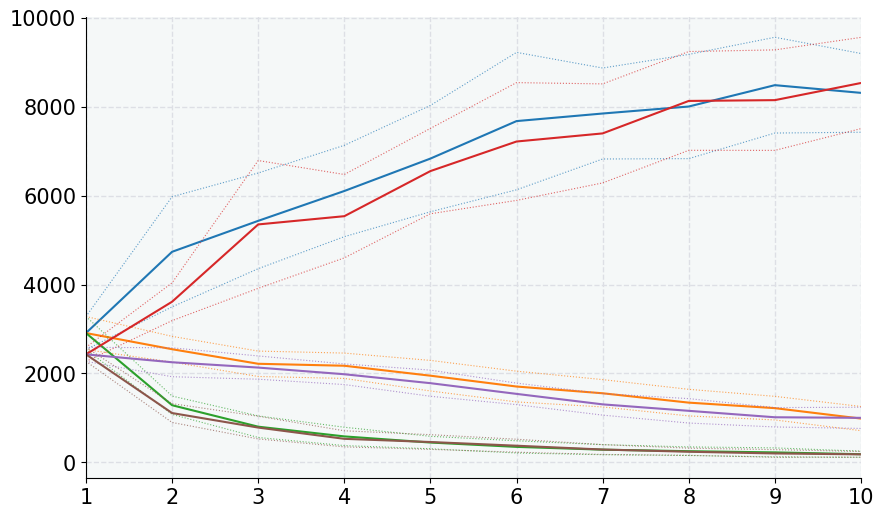

<Figure size 640x480 with 0 Axes>

In [82]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_steps'],
    std=std_per_agent['n_steps'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Steps",
    show_std=False,
     show_std2=True,
)
fig.savefig(f'{scenario}_steps.png', bbox_inches='tight')

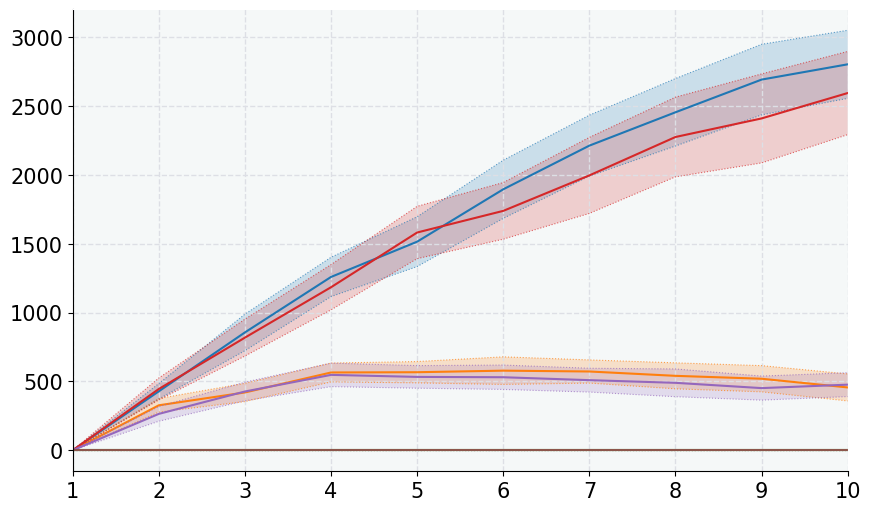

<Figure size 640x480 with 0 Axes>

In [83]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['postponements'],
    std=std_per_agent['postponements'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Postponments",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_postpones.png', bbox_inches='tight')

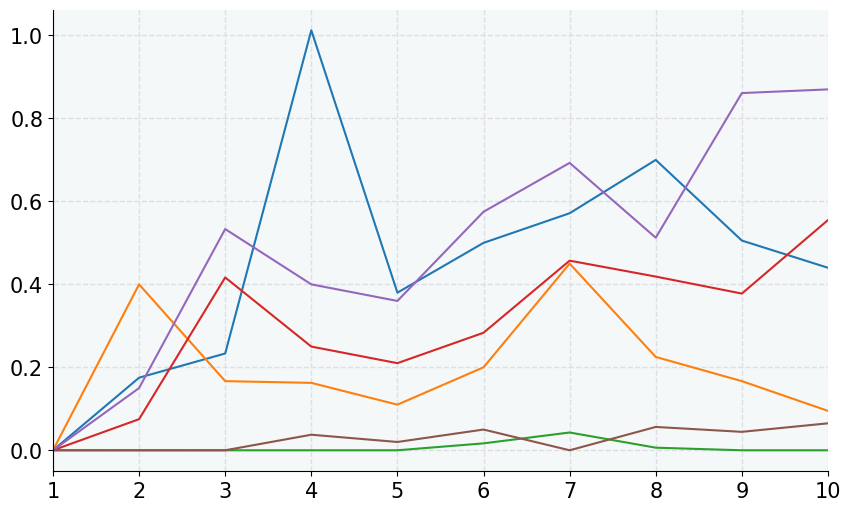

<Figure size 640x480 with 0 Axes>

In [84]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_planning_timeouts'],
    std=std_per_agent['n_planning_timeouts'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Timeouts",
    show_std=False
)
fig.savefig(f'{scenario}_timeouts.png', bbox_inches='tight')

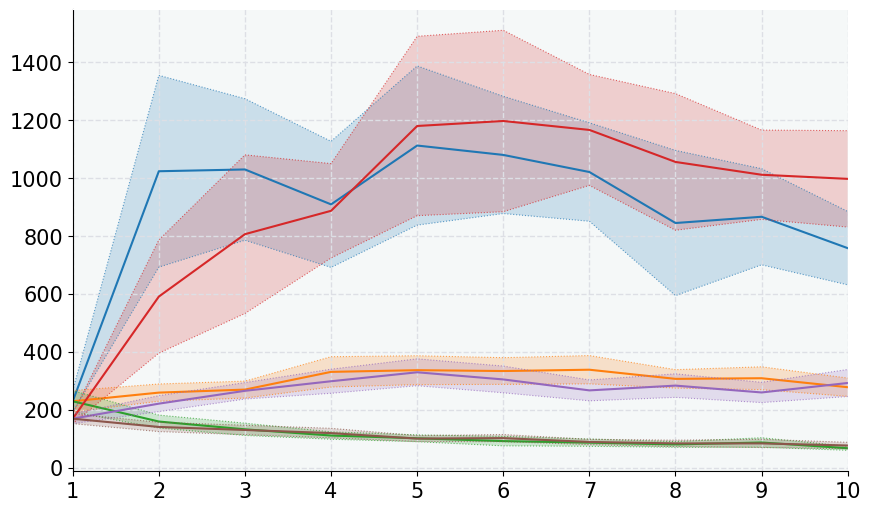

<Figure size 640x480 with 0 Axes>

In [85]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_make_span['n_steps'],
    std=std_make_span['n_steps'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Make-Span",
    show_std=True,
    show_std2=True,
)
fig.savefig(f'{scenario}_make_span.png', bbox_inches='tight')